# Cognifyz Data Analysis Internship

## Level 2 - Task 4

### Restaurant Chains

#### Objective

- Identify whether restaurant chains are present in the dataset.
- Analyze the ratings and popularity of different restaurant chains.

**Prepared By:** Suraj Kumar

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset .csv")

In [3]:
df.shape

(9551, 21)

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
restaurant_count = df["Restaurant Name"].value_counts()

restaurant_count.head(10)


Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [6]:
restaurant_chains = restaurant_count[restaurant_count > 1]

restaurant_chains.head(10)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [7]:
print("Total Restaurant Chains :", len(restaurant_chains))

Total Restaurant Chains : 734


In [8]:
top10_chains = restaurant_chains.head(10)

top10_chains

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

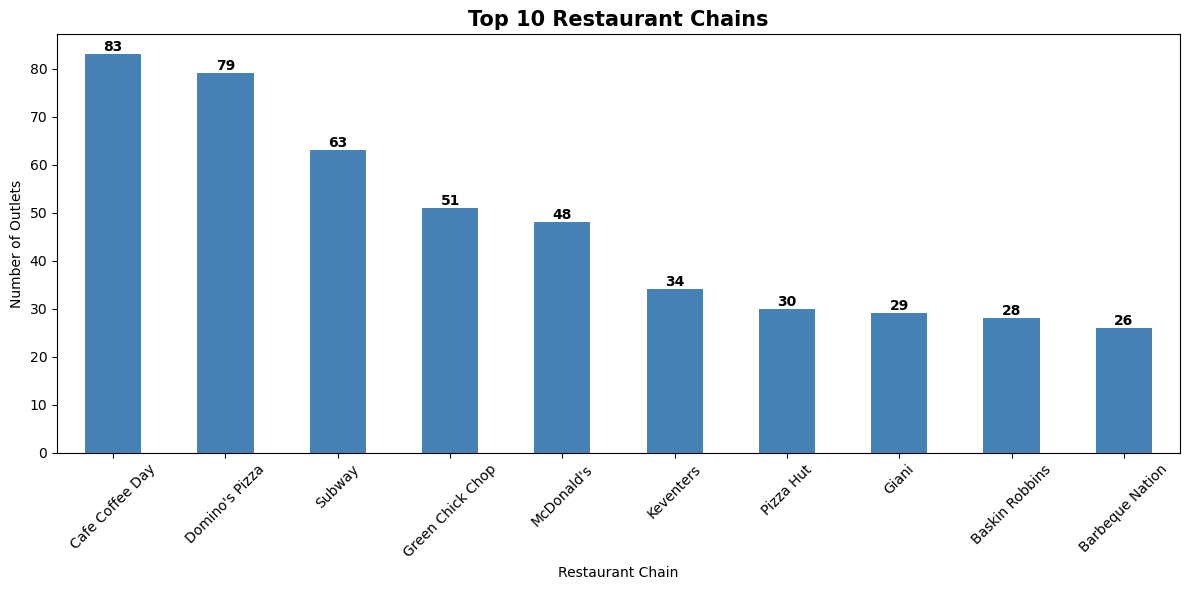

In [9]:
plt.figure(figsize=(12,6))

ax = top10_chains.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Restaurant Chains", fontsize=15, fontweight="bold")
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Outlets")

plt.xticks(rotation=45)

# Data Labels
for bar in ax.patches:
    ax.annotate(
        str(int(bar.get_height())),
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Insights

- Several restaurant names appear multiple times in the dataset, indicating the presence of restaurant chains.
- The top restaurant chains have multiple outlets across different locations.
- Restaurant chains have a stronger market presence than single-outlet restaurants.

## Conclusion

The dataset contains several restaurant chains with multiple outlets. These chains have expanded across different cities, making them more accessible and popular among customers.

## Question 2

### Analyze the ratings and popularity of different restaurant chains.

In [10]:
chain_ratings = df.groupby("Restaurant Name").agg({
    "Aggregate rating":"mean",
    "Votes":"sum"
})

In [11]:
chain_ratings = chain_ratings.loc[restaurant_chains.index]

chain_ratings.head()

,Aggregate rating,Votes
Restaurant Name,,
Cafe Coffee Day,2.419277,2428
Domino's Pizza,2.740506,6643
Subway,2.907937,6124
Green Chick Chop,2.672549,964
McDonald's,3.339583,5291


In [12]:
highest_rated = chain_ratings.sort_values(
    by="Aggregate rating",
    ascending=False
).head(10)

highest_rated

,Aggregate rating,Votes
Restaurant Name,,
Talaga Sampireun,4.900,5514
Silantro Fil-Mex,4.850,1364
AB's Absolute Barbecues,4.850,3151
AB's - Absolute Barbecues,4.825,13400
Naturals Ice Cream,4.800,3094
Gymkhana,4.700,328
The Cheesecake Factory,4.650,3010
Dishoom,4.600,1269
Garota de Ipanema,4.600,59


In [13]:
most_popular = chain_ratings.sort_values(
    by="Votes",
    ascending=False
).head(10)

most_popular

,Aggregate rating,Votes
Restaurant Name,,
Barbeque Nation,4.353846,28142
AB's - Absolute Barbecues,4.825000,13400
Big Chill,4.475000,10853
Farzi Cafe,4.366667,10098
Truffles,3.950000,9682
Chili's,4.580000,8156
Joey's Pizza,4.250000,7807
Big Yellow Door,4.266667,7511
Saravana Bhavan,4.133333,7238


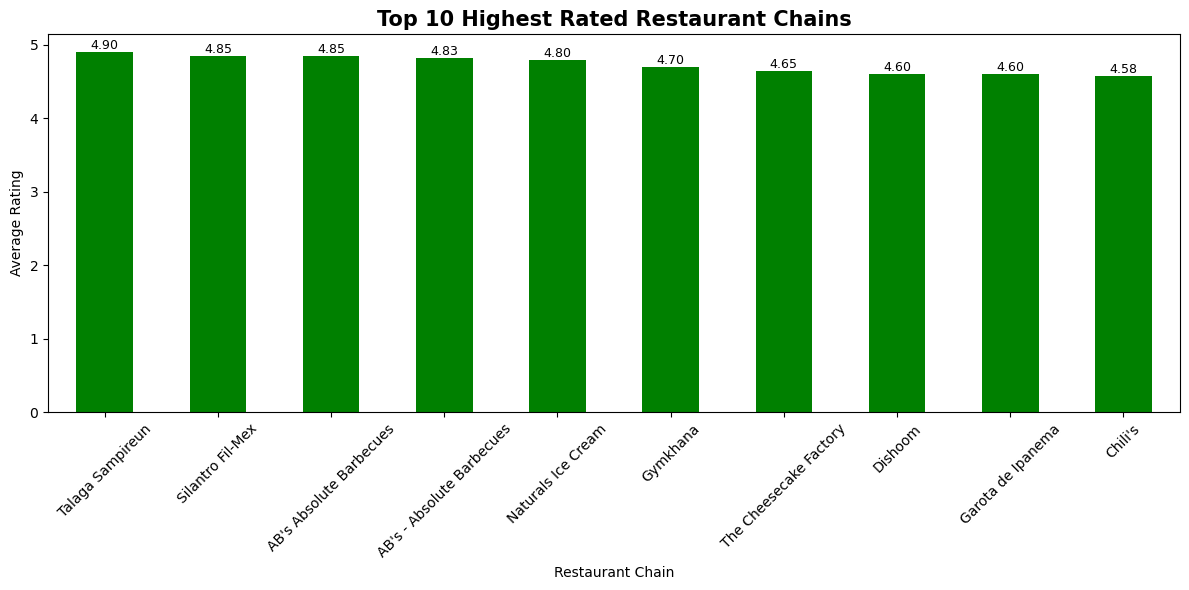

In [14]:
plt.figure(figsize=(12,6))

ax = highest_rated["Aggregate rating"].plot(
    kind="bar",
    color="green"
)

plt.title("Top 10 Highest Rated Restaurant Chains", fontsize=15, fontweight="bold")
plt.xlabel("Restaurant Chain")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

# Data Labels
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.2f}",
        (bar.get_x()+bar.get_width()/2,
         bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

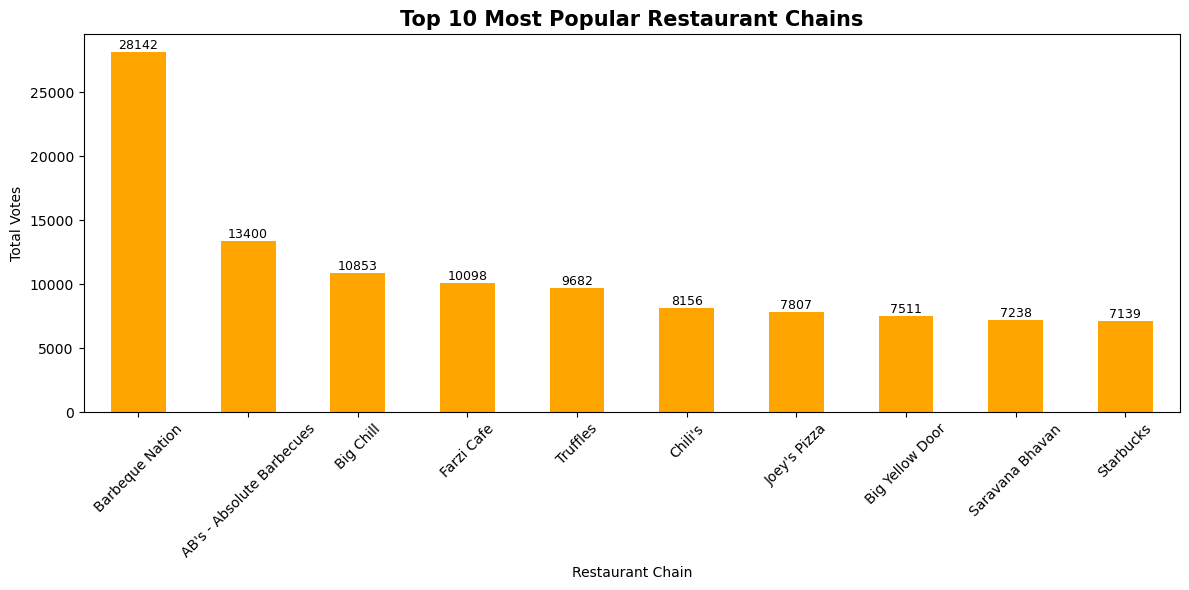

In [15]:
plt.figure(figsize=(12,6))

ax = most_popular["Votes"].plot(
    kind="bar",
    color="orange"
)

plt.title("Top 10 Most Popular Restaurant Chains", fontsize=15, fontweight="bold")
plt.xlabel("Restaurant Chain")
plt.ylabel("Total Votes")

plt.xticks(rotation=45)

# Data Labels
for bar in ax.patches:
    ax.annotate(
        str(int(bar.get_height())),
        (bar.get_x()+bar.get_width()/2,
         bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

## Insights

- Restaurant chains with higher average ratings indicate better customer satisfaction.
- Chains receiving more votes are generally more popular among customers.
- Some restaurant chains have high ratings but fewer votes, while others have many votes with moderate ratings.
- Popularity and customer ratings do not always increase together.

## Conclusion

The analysis shows that some restaurant chains consistently maintain high customer ratings, while others are more popular based on the number of customer votes. Evaluating both ratings and votes provides a better understanding of customer satisfaction and restaurant popularity.